# Lab 14: clasificador de latas Monster / Red Bull

**Integrantes:** Mathias Carrera, Bastian Contreras

**Clases:**
- `monster`: lata de Monster Energy, de cualquier sabor y color.
- `redbull`: lata de Red Bull, de cualquier sabor y color.
- `ninguna`: no hay ninguna de las dos (vaso de agua, otras bebidas, objetos, fondos sin lata).

**Por qué:** queremos un modelo que reconozca las dos marcas y además sepa decir cuándo no hay ninguna, no que fuerce una de las dos. La clase `ninguna` incluye objetos parecidos (vasos, botellas, otras latas) para que no se limite a detectar "una lata".

**Criterio de etiquetado:** la clase es la marca de la lata visible en la foto. Si hay una lata de cada una, no se usa la foto. Si la marca no se distingue, tampoco. Todas las fotos son propias, tomadas con celular y reducidas a 512 px.

## Imports

In [12]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torchmetrics
import torchvision
from lightning.pytorch import LightningModule, Trainer, seed_everything
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder

seed_everything(42)

Seed set to 42


42

## Datos

In [13]:
IMAGENET_MEAN, IMAGENET_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Dos vistas de data/train: una con aumento de datos (entrenar) y otra sin (validar)
train_full = ImageFolder("data/train", transform=train_transform)
val_full = ImageFolder("data/train", transform=eval_transform)
test_ds = ImageFolder("data/test", transform=eval_transform)

CLASS_NAMES = train_full.classes
NUM_CLASSES = len(CLASS_NAMES)

# Validación por bloques: las fotos consecutivas de una clase suelen ser ráfagas casi idénticas.
# Se separan bloques completos (~20 % de cada clase) para que la validación no tenga
# "gemelas" en el entrenamiento y mida mejor la generalización.
BLOCK = 4
rng = random.Random(42)
train_idx, val_idx = [], []
for class_index in range(NUM_CLASSES):
    indices = [i for i, (_, y) in enumerate(train_full.samples) if y == class_index]
    blocks = [indices[k:k + BLOCK] for k in range(0, len(indices), BLOCK)]
    rng.shuffle(blocks)
    n_val_blocks = max(1, round(0.2 * len(blocks)))
    for block in blocks[:n_val_blocks]:
        val_idx += block
    for block in blocks[n_val_blocks:]:
        train_idx += block

train_ds = Subset(train_full, train_idx)
val_ds = Subset(val_full, val_idx)

# Pesos por clase (inverso de la frecuencia en entrenamiento): ninguna tiene menos fotos
train_counts = torch.bincount(torch.tensor([train_full.targets[i] for i in train_idx]), minlength=NUM_CLASSES)
CLASS_WEIGHTS = len(train_idx) / (NUM_CLASSES * train_counts.float())

# drop_last evita un último lote de 1 foto, que rompe BatchNorm en modo entrenamiento
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=32)
test_loader = DataLoader(test_ds, batch_size=32)

print(CLASS_NAMES)
print("pesos por clase:", [round(w, 2) for w in CLASS_WEIGHTS.tolist()])
for split in ("train", "test"):
    counts = {c: sum(p.suffix.lower() in IMAGE_EXTENSIONS for p in Path(f"data/{split}/{c}").iterdir())
              for c in CLASS_NAMES}
    print(split, counts)
print("entrenamiento:", len(train_ds), "| validación:", len(val_ds), "| test:", len(test_ds))


['monster', 'ninguna', 'redbull']
pesos por clase: [0.82, 5.21, 0.63]
train {'monster': 63, 'ninguna': 12, 'redbull': 82}
test {'monster': 15, 'ninguna': 6, 'redbull': 15}
entrenamiento: 125 | validación: 32 | test: 36


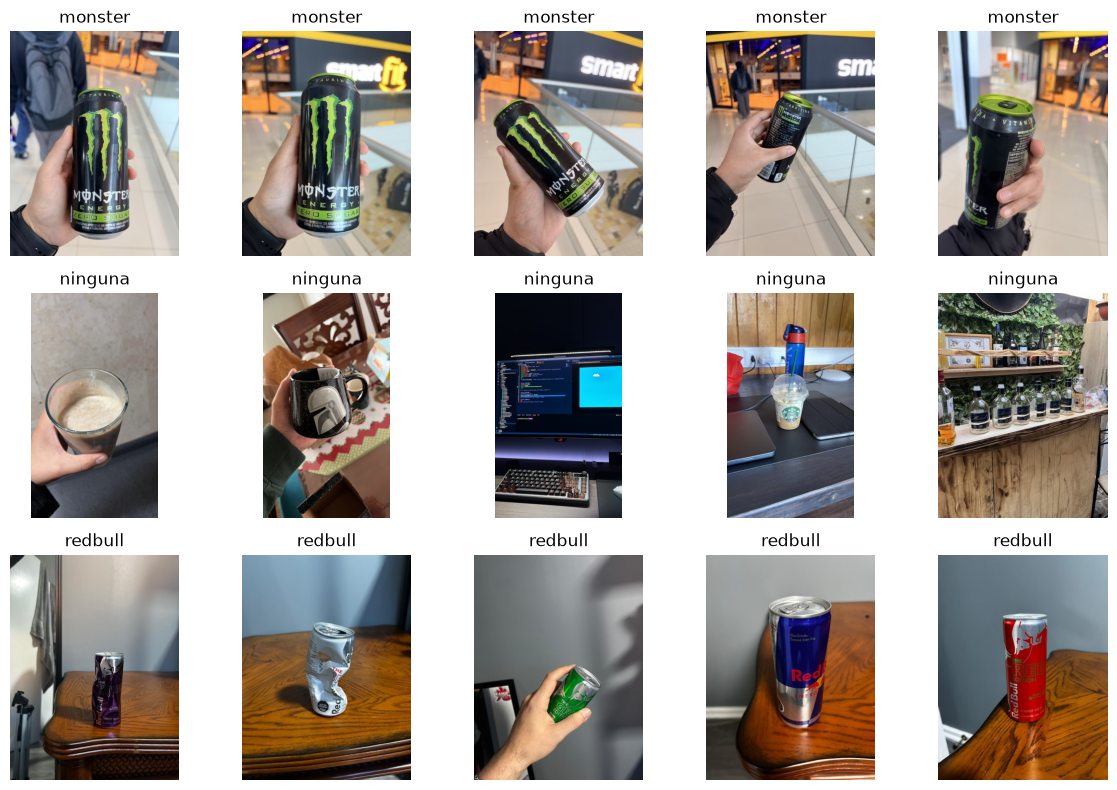

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
for row, class_index in enumerate(range(NUM_CLASSES)):
    samples = [i for i, (_, y) in enumerate(val_full.samples) if y == class_index][:5]
    for axis, i in zip(axes[row], samples):
        axis.imshow(plt.imread(val_full.samples[i][0]))
        axis.set_title(CLASS_NAMES[class_index])
        axis.axis("off")
plt.tight_layout()
plt.show()

## Modelo: ResNet-18 pre-entrenada con fine-tuning

In [15]:
class CanModel(LightningModule):
    def __init__(self, num_classes, lr=3e-4, class_weights=None):
        super().__init__()
        self.save_hyperparameters(ignore=["class_weights"])
        self.register_buffer("class_weights", class_weights)
        self.model = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        self.model.fc = nn.Linear(512, num_classes)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.test_acc = torchmetrics.Accuracy(task="multiclass", num_classes=num_classes)
        self.confmat = torchmetrics.ConfusionMatrix(task="multiclass", num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_nb):
        x, y = batch
        loss = F.cross_entropy(self(x), y, weight=self.class_weights)
        self.log("train_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_nb):
        x, y = batch
        out = self(x)
        self.val_acc(out, y)
        self.log("val_acc", self.val_acc, on_epoch=True, prog_bar=True)
        self.log("val_loss", F.cross_entropy(out, y, weight=self.class_weights), prog_bar=True)

    def test_step(self, batch, batch_nb):
        x, y = batch
        out = self(x)
        self.test_acc(out, y)
        self.confmat.update(out, y)
        self.log("test_acc", self.test_acc, on_epoch=True, prog_bar=True)
        self.log("test_loss", F.cross_entropy(out, y), prog_bar=True)

    def on_test_epoch_end(self):
        cm = self.confmat.compute()
        fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(cm.cpu().numpy(), cmap="Blues")
        ax.set_xticks(range(len(CLASS_NAMES)))
        ax.set_yticks(range(len(CLASS_NAMES)))
        ax.set_xticklabels(CLASS_NAMES)
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicción")
        ax.set_ylabel("Real")
        for i in range(len(CLASS_NAMES)):
            for j in range(len(CLASS_NAMES)):
                ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                        color="white" if cm[i, j] > cm.max() / 2 else "black")
        ax.set_title("Matriz de confusión (test)")
        fig.colorbar(im)
        plt.show()
        print(cm)
        self.confmat.reset()

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

## Entrenamiento

In [16]:
model = CanModel(NUM_CLASSES, lr=3e-4, class_weights=CLASS_WEIGHTS)
checkpoint = ModelCheckpoint(dirpath="log/checkpoints", save_top_k=1, monitor="val_loss", mode="min")

trainer = Trainer(
    accelerator="auto",
    max_epochs=25,
    log_every_n_steps=5,
    logger=TensorBoardLogger("log"),
    callbacks=[checkpoint],
)
trainer.fit(model, train_loader, val_loader)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/.venv/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/log/checkpoints exists and is not empty.

  | Name     | Type                      | Params | Mode  | FLOPs
-----------------------------------------------------------------------
0 | model    | ResNet                    | 11.2 M | train | 0    
1 | val_acc  | Mul

Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/.venv/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:321: The number of training batches (3) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 24: 100%|██████████| 3/3 [00:00<00:00,  3.09it/s, v_num=1, train_loss_step=0.00155, val_acc=0.969, val_loss=0.555, train_loss_epoch=0.000598] 

`Trainer.fit` stopped: `max_epochs=25` reached.


Epoch 24: 100%|██████████| 3/3 [00:00<00:00,  3.09it/s, v_num=1, train_loss_step=0.00155, val_acc=0.969, val_loss=0.555, train_loss_epoch=0.000598]


## Evaluación en test

Restoring states from the checkpoint path at /Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/log/checkpoints/epoch=19-step=60-v1.ckpt
Loaded model weights from the checkpoint at /Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/log/checkpoints/epoch=19-step=60-v1.ckpt
/Users/basti/Library/CloudStorage/OneDrive-UniversidadSanSebastian/Universidad/Semestre-2-2026/IA/Unidad 2/Laboratorios/Laboratorio 14/energy-drink-classifier/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 24.66it/s]

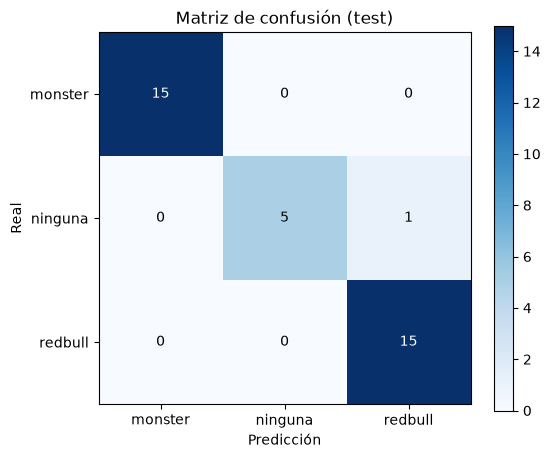

tensor([[15,  0,  0],
        [ 0,  5,  1],
        [ 0,  0, 15]], device='mps:0')
Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 12.00it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_acc            0.9722222089767456
        test_loss           0.17117030918598175
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_acc': 0.9722222089767456, 'test_loss': 0.17117030918598175}]

In [17]:
trainer.test(model, dataloaders=test_loader, ckpt_path="best")

## Predicciones sobre el test

errores en test: 1 de 36


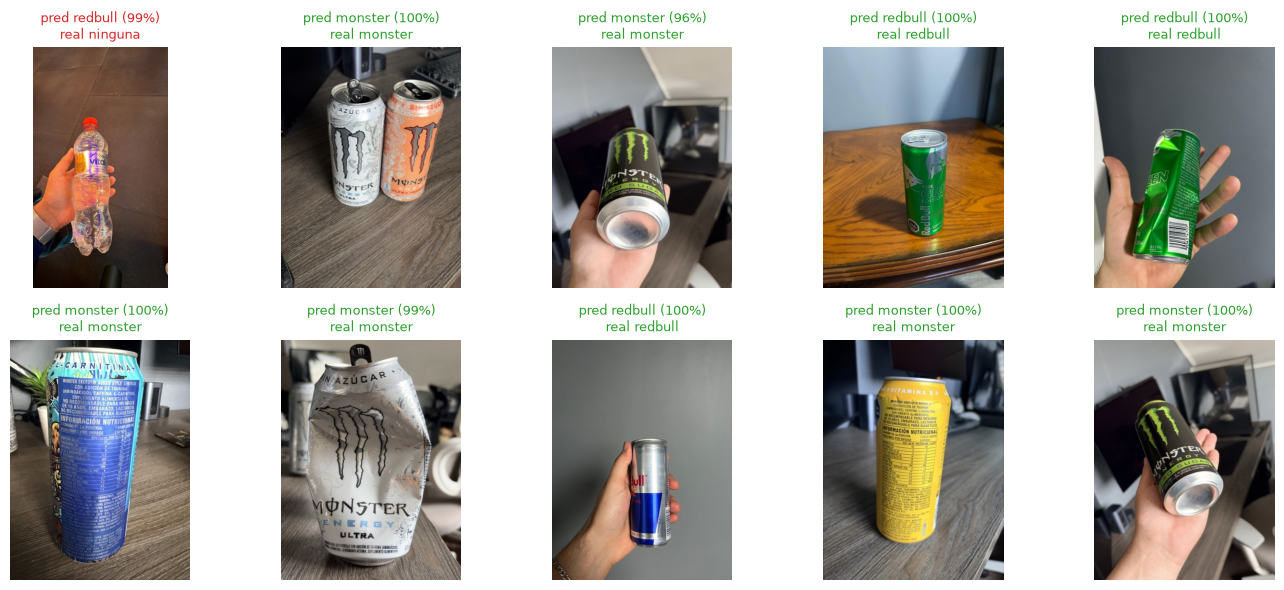

In [19]:
model.eval()
paths = [p for p, _ in test_ds.samples]

results = []
for i in range(len(test_ds)):
    x, y = test_ds[i]
    with torch.no_grad():
        probs = F.softmax(model(x.unsqueeze(0).to(model.device)), dim=1)[0].cpu()
    results.append((i, y, probs.argmax().item(), probs.max().item()))

# Primero los errores, después aciertos al azar, hasta completar 10
wrong = [r for r in results if r[1] != r[2]]
right = [r for r in results if r[1] == r[2]]
random.Random(0).shuffle(right)
shown = (wrong + right)[:10]
print(f"errores en test: {len(wrong)} de {len(results)}")

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for axis, (i, y, pred, confidence) in zip(axes.flatten(), shown):
    axis.imshow(plt.imread(paths[i]))
    axis.set_title(f"pred {CLASS_NAMES[pred]} ({confidence:.0%})\nreal {CLASS_NAMES[y]}",
                   color="tab:green" if pred == y else "tab:red", fontsize=9)
    axis.axis("off")
plt.tight_layout()
plt.show()
